# Build and Test Clustering 

Using subject (genre), category, page counts, published date

#### Imports and Data 

In [188]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS


In [189]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
print(df.shape)
df.head()

(720, 18)


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description,publish_year,page_count_scaled,publish_year_scaled,cluster_13,cluster_14,cluster,cluster_12
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ...",2012,0.184353,0.628571,11,11,1,11
1,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...,2006,0.095714,0.457143,11,11,1,11
2,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...,2001,0.143154,0.314286,11,11,1,11
3,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...,1998,0.123179,0.228571,11,11,1,11
4,There There,Tommy Orange,Vintage,fiction,Fiction,NOT_MATURE,260,5.0,2,2018-06-05,PULITZER PRIZE FINALIST • NATIONAL BESTSELLER ...,2018,0.103204,0.800000,11,11,1,11


#### Publishing Year extract 

In [190]:
#just get year 
df["publish_year"] = df["published_date"].dt.year

In [191]:
#check for missing dates 
df["publish_year"].isna().sum()

#if missing dates, fill with median year
median_year = df["publish_year"].median()
df["publish_year"] = df["publish_year"].fillna(median_year)

In [192]:
#year range 
print(f"publish year range: {df['publish_year'].min()} - {df['publish_year'].max() }")

publish year range: 1990 - 2025


#### normalize page counts and publish year 

In [193]:
scaler = MinMaxScaler()

#scale to be between 0 and 1 for clustering
# df["page_count_scaled"] = scaler.fit_transform(df[["page_count"]])
# df["publish_year_scaled"] = scaler.fit_transform(df[["publish_year"]])
df[["page_count_scaled", "publish_year_scaled"]] = scaler.fit_transform(df[["page_count", "publish_year"]])

#confirm 
print(df[["page_count_scaled", "publish_year_scaled"]].describe())


       page_count_scaled  publish_year_scaled
count         720.000000           720.000000
mean            0.145636             0.497460
std             0.077628             0.269995
min             0.000000             0.000000
25%             0.098211             0.285714
50%             0.133167             0.485714
75%             0.176654             0.750000
max             1.000000             1.000000


#### Encode genres and categories

In [194]:
#turn genre into indicator columns with one hot encoding
subject_dummies = pd.get_dummies(df["subject"], prefix="subject")
subject_dummies.head()

,subject_biography,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,subject_self help,subject_thriller
0,False,False,True,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [195]:
#turn categories into indicator columns with one hot encoding

#first deal with instances of list of categories 
category_dummies = df["categories"].str.get_dummies(sep=",")
#add prefix to columns
category_dummies.columns = ["category_"+col for col in category_dummies.columns]
category_dummies.head()

,category_ 1921-1922,category_ Ancient,category_ Calif.),"category_ Charlie ""Bird"" (Fictitious character)",category_ Mind & Spirit,category_ N.Y.),category_ Temperance (Fictitious character),category_Abduction,category_Abused women,category_Accelerated reader,...,category_Science,category_Self,category_Self-Help,category_Social Science,category_Technology & Engineering,category_Thriller - Fiction,category_Travel,category_Unknown,category_Young Adult Fiction,category_Young Adult Nonfiction
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [196]:
#keep categories that appear in at least 5 books 
cat_columns = category_dummies.columns.tolist()
keep_cats = [col for col in cat_columns if category_dummies[col].sum() >= 5]

print("before category columns: ", len(cat_columns))
print("after category columns: ", len(keep_cats))

before category columns:  109
after category columns:  24


#### Add in TF-IDF to extract key words from description

In [311]:
df["description"] = df["description"].fillna("")

#create stop words list 
custom_stopwords = [
    # your original list
    'author', 'bestselling', 'book', 'books', 'novel', 'story', 'edition', 
    'fiction', 'history', 'just', 'make', 'man', 'new', 'readers', 'set', 
    'times', 'way', 'woman', 'written', 'years', 'york', 'best', 'literature', 
    'novels', 'published', 'research', 'science', 'series', 'stories', 'like', 
    'life', 'lives', 'home', 'world', 'time', 'people', 'long', 'old', 'young', 
    'great', 'known', 'journey', 'past', 'future', 'age', 'year',
    'including', 'important', 'information', 'use', 'work', 'works',
    'understanding', 'second', 'explores', 'finds', 'takes', 'offers', 'provides', 'read',
    'end', 'day', 'tale', 'ways', 'classic', 'original', 'comes', 'need', 'small', 'questions', 'public', 'personal',
    'authors', 'based', 'clear', 'different', 'experience', 'little', 'secrets', 'american', 'english', 'll', 'literary', 'makes',
    'powerful', 'tells', 'volume', 'writer', 'title'


]
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stopwords))

#tf-idf, max features 100
tfidf = TfidfVectorizer(
    max_features=75, #100 most meaningful words 
    stop_words = all_stop_words,
    min_df = 3 #word must appear in at least 3 books 
)

tfidf_matrix = tfidf.fit_transform(df['description']).toarray()
tfidf_df = pd.DataFrame(
    tfidf_matrix,
    columns = [f"tfidf_{term}" for term in tfidf.get_feature_names_out()]
)


print(f"tf-idf terms created: {tfidf_df.shape[1]}")
print("top words ", tfidf.get_feature_names_out().tolist())

tf-idf terms created: 75
top words  ['america', 'ancient', 'art', 'beautiful', 'body', 'career', 'case', 'century', 'change', 'children', 'city', 'climate', 'comprehensive', 'control', 'cultural', 'dark', 'daughter', 'death', 'detective', 'development', 'discover', 'discovery', 'earth', 'extraordinary', 'face', 'family', 'fantasy', 'father', 'field', 'friend', 'girl', 'good', 'guide', 'heart', 'help', 'historical', 'house', 'human', 'king', 'know', 'knowledge', 'learn', 'left', 'london', 'love', 'men', 'modern', 'mother', 'murder', 'mystery', 'nature', 'philosophy', 'political', 'popular', 'power', 'real', 'relationship', 'scientific', 'scientists', 'secret', 'self', 'simple', 'social', 'society', 'studies', 'study', 'technology', 'theory', 'thought', 'today', 'town', 'truth', 'turns', 'war', 'women']


#### combine all features

In [330]:
#feature weighting 
feature_weights = {
    "page":  0.5,
    "publish": 1.5, 
    "subject":  2.5,
    "category": 2.0,
    "tfidf":    2.0,
}
numeric = pd.concat([
    df["page_count_scaled"] * feature_weights["page"],
    df["publish_year_scaled"] * feature_weights["publish"],
], axis=1)

features = pd.concat([
    numeric,
    subject_dummies * feature_weights["subject"],
    category_dummies[keep_cats] * feature_weights["category"],
    tfidf_df * feature_weights["tfidf"]
], axis = 1)



In [331]:
print("features shape: ", features.shape)
features.head()

features shape:  (720, 112)


,page_count_scaled,publish_year_scaled,subject_biography,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,...,tfidf_study,tfidf_technology,tfidf_theory,tfidf_thought,tfidf_today,tfidf_town,tfidf_truth,tfidf_turns,tfidf_war,tfidf_women
0,0.092176,0.942857,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
1,0.047857,0.685714,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,0.071577,0.471429,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.372516,0.0,0.699377,0.0,0.686258,0.0,0.662906
3,0.061590,0.342857,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
4,0.051602,1.200000,0.0,0.0,2.5,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000


In [332]:
#check null 
features.isna().sum().sum()

np.int64(0)

In [333]:
# df[df["categories"] == "Unknown"]

### K Means

Find K value - elbow method 

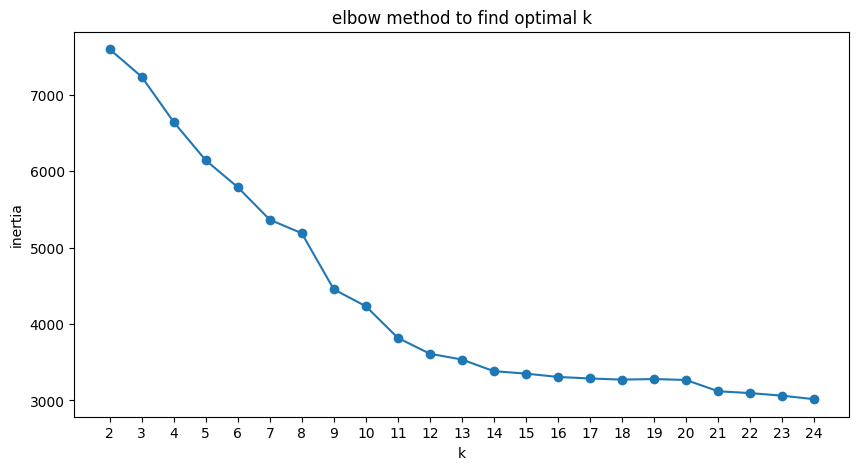

In [334]:
inertia = [] #track how tight clusters are
k_range = range(2, 25)

#test out ks 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

#plot inertia to find elbow point
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker="o")
plt.title("elbow method to find optimal k")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_range)
plt.show()

somewhere in k = 12


In [335]:
for k in [10, 13]:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    df[f"cluster_{k}"] = kmeans.labels_
    print(f"\n{k} clusters")
    print(df[f"cluster_{k}"].value_counts().sort_index())


10 clusters
cluster_10
0     72
1     69
2     49
3    133
4     90
5     72
6     73
7     64
8     61
9     37
Name: count, dtype: int64

13 clusters
cluster_13
0     72
1     69
2     49
3     46
4     49
5     37
6     73
7     64
8     61
9      9
10    78
11    78
12    35
Name: count, dtype: int64


In [336]:
for cluster_id in [7]:
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_books = df[df["cluster_12"] == cluster_id]
    print("Subjects:", cluster_books["subject"].value_counts().to_dict())
    print("Categories:", cluster_books["categories"].value_counts().head(5).to_dict())
    print("Titles:", cluster_books["title"].tolist())


--- Cluster 7 ---
Subjects: {'science fiction': 55}
Categories: {'Science': 14, 'Unknown': 9, 'Fiction': 7, 'Biography & Autobiography': 5, 'Education': 4}
Titles: ['The Philosophy of Science Fiction Film', 'Science Fact and Science Fiction', 'Science Fiction Prototyping', 'Science Fiction', 'The Supernatural and English Fiction', 'Stranger Than Fiction', 'The Country of the Pointed Firs and Other Fiction', 'Music in Contemporary British Fiction', 'The First Men in the Moon', 'Holt Anthology of Science Fiction', 'The History of Science Fiction', "The Invisible Man and The Island of Dr. Moreau (A Reader's Library Classic Hardcover)", 'Second Variety', 'American Novelists Since World War II.', 'Different Engines', 'Analog Essays on Science', 'Exploitation, Conservation, Preservation', 'Science & Public Policy', 'Integrating Science and Language Arts', 'Student Handbook', 'In Situ Hybridization', 'Bits of Life', 'Brigands of the Moon', 'Holy Sci-Fi!', 'Discover', 'British Travel Writers,

k = 12 best 


In [337]:
kmeans = KMeans(n_clusters=12, random_state=123, n_init=10)
kmeans.fit(features)
df["cluster"] = kmeans.labels_

print(df["cluster"].value_counts().sort_index())

cluster
0     64
1     73
2     69
3     61
4     72
5     78
6     72
7     43
8     49
9     55
10    49
11    35
Name: count, dtype: int64


### PCA 

In [338]:
pca = PCA(n_components=2, random_state=123)
pca_features = pca.fit_transform(features)

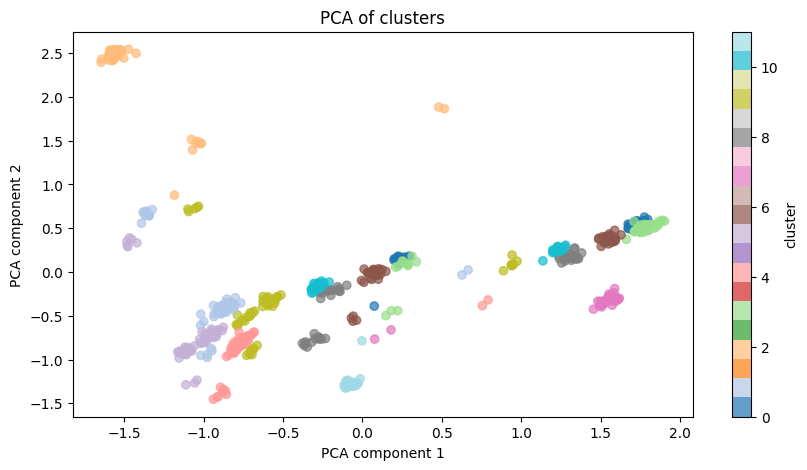

In [339]:
#plot PCA components colored by cluster
plt.figure(figsize=(10,5))
scatter = plt.scatter(
    pca_features[:,0], #x axis , first PCA component
    pca_features[:,1], #y axis, second PCA component
    c=df["cluster"],  # color by cluster assignment
    cmap="tab20", #20 distinct colors
    alpha=0.7
)
plt.colorbar(scatter, label="cluster")
plt.title("PCA of clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

look at each cluster 

In [340]:
for i in range(12):
    print(f"cluster {i}")
    cluster_books = df[df["cluster"] == i]
    print("subjects: ", cluster_books["subject"].value_counts().to_dict())
    print("categories: ", cluster_books["categories"].value_counts().to_dict())
    print("titles: ", cluster_books["title"].tolist()[:5]) 


cluster 0
subjects:  {'mystery': 64}
categories:  {'Fiction': 46, 'Detective and mystery stories': 3, 'Juvenile Fiction': 3, 'Drama': 2, 'Anthropology': 1, 'Large print books': 1, 'Aircraft accidents': 1, 'Unknown': 1, 'Botswana': 1, 'Boarding schools': 1, 'Adventure fiction': 1, 'Folklore': 1, 'Large type books': 1, 'Hollywood (Los Angeles, Calif.)': 1}
titles:  ['Missing Joseph', 'The Sleeping Doll', 'Tyrannosaur Canyon', 'The Runaway Jury', 'The Colorado Kid']
cluster 1
subjects:  {'nonfiction': 73}
categories:  {'Biography & Autobiography': 11, 'History': 8, 'Business & Economics': 7, 'Unknown': 5, 'Nature': 4, 'Juvenile Nonfiction': 4, 'Cooking': 3, 'Science': 3, 'Health & Fitness': 3, 'Body, Mind & Spirit': 2, 'Family & Relationships': 2, 'Medical': 2, 'Fiction': 2, 'Philosophy': 2, 'Gardening': 2, 'Social Science': 2, 'BIOGRAPHY & AUTOBIOGRAPHY': 1, 'Computers': 1, 'Mathematics': 1, 'Critical thinking': 1, 'Art': 1, 'Travel': 1, 'Photography': 1, 'Jungian psychology': 1, 'Capita

#### Save Model 

In [341]:
import joblib

#save model 
joblib.dump(kmeans, "../data/kmeans_model.pkl")

#save feature matrix column names 
joblib.dump(features.columns.tolist(), "../data/feature_columns.pkl")

#save features
joblib.dump(features, "../data/features.pkl")

#save features weights 
joblib.dump(feature_weights, "../data/feature_weights.pkl")


#save scalar for page count and publish year 
joblib.dump(scaler, "../data/scaler.pkl")

#save tf-idf
joblib.dump(tfidf, "../data/tfidf_vectorizer.pkl")

#save clustered data
df.to_csv("../data/books.csv", index=False)


